In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import s3fs
import xarray as xr
import os

access_key = os.getenv("AWS_ACCESS_KEY_ID")
secret_key = os.getenv("AWS_SECRET_ACCESS_KEY")
bucket_name = os.getenv("KOPAH_BUCKET")
endpoint = "https://s3.kopah.uw.edu"

# Xarray dark mode hack
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
fs = s3fs.S3FileSystem(
    key=os.environ["AWS_ACCESS_KEY_ID"],
    secret=os.environ["AWS_SECRET_ACCESS_KEY"],
    client_kwargs={"endpoint_url": os.environ["S3_ENDPOINT_URL"]}
)

In [8]:
with fs.open('gaia/cjense/data/airtemp/KPC_U_mixed.nc', mode='rb') as f:
    ds = xr.open_dataset(f, engine='h5netcdf')
    
    ds.load()

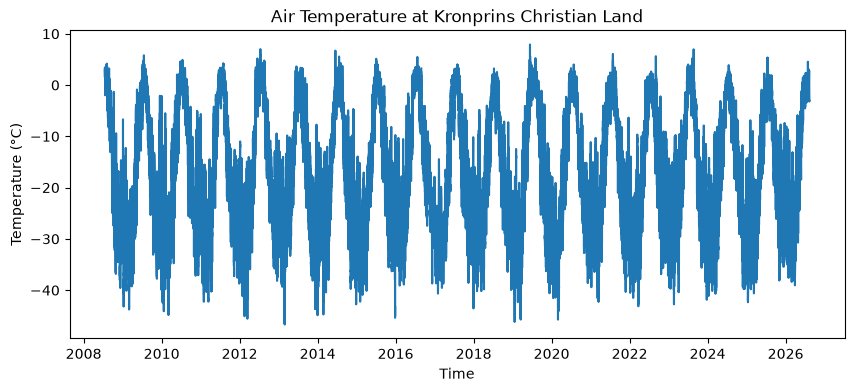

In [12]:
fig, ax = plt.subplots(figsize=(10,4))
plt.plot(ds.time, ds.t_u)

plt.xlabel('Time')
plt.ylabel("Temperature (°C)")
plt.title('Air Temperature at Kronprins Christian Land')

plt.show()